# DỰ ĐOÁN BURNOUT SCORE BẰNG MACHINE LEARNING

**Target:** `burnout_level`

**Bài toán:** Hồi quy Logistic

**Các thuật toán sử dụng:**
- Logistic Regression


1. Đọc và kiểm tra dữ liệu

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

train_df = pd.read_csv(
    "../data/burnout_train_standardized.csv")
test_df = pd.read_csv(
    "../data/burnout_test_standardized.csv")

print("Kích thước Train:", train_df.shape)
print("Kích thước Test:", test_df.shape)

display(train_df.head())

Kích thước Train: (76001, 38)
Kích thước Test: (19001, 38)


,numeric__age,numeric__years_experience,numeric__salary_usd,numeric__work_hours_per_week,numeric__sleep_hours_per_night,numeric__uses_therapy,numeric__ai_tools_daily,numeric__deadline_pressure_score,numeric__stress_score,numeric__phq9_score,...,categorical__seniority_level_Lead,categorical__seniority_level_Manager,categorical__seniority_level_Mid,categorical__seniority_level_Principal,categorical__seniority_level_Senior,categorical__work_mode_Hybrid,categorical__work_mode_On-site,categorical__work_mode_Remote,burnout_level,burnout_level_encoded
0,-0.829642,-0.837757,-0.747030,0.361485,-0.904198,-0.423133,0.609315,0.176305,-0.497060,0.148301,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Low,0
1,-0.361696,-0.212010,-0.823270,0.170671,-0.003904,-0.423133,0.609315,1.533801,0.630967,0.148301,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,High,2
2,1.354110,1.508794,0.736754,0.170671,-1.204297,-0.423133,0.609315,0.006618,-1.155075,-0.053721,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,Low,0
3,-0.361696,-0.212010,0.235713,-0.783400,1.496587,2.363325,0.609315,0.628804,-1.061073,-0.053721,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Low,0
4,2.445986,2.447414,-1.098358,1.124743,0.596292,2.363325,0.609315,-2.934621,-1.014072,-0.861809,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Low,0


In [37]:
X_train = train_df.drop(
    columns=["burnout_level", "burnout_level_encoded"]
)
y_train = train_df["burnout_level_encoded"]

X_test = test_df.drop(
    columns=["burnout_level", "burnout_level_encoded"]
)
y_test = test_df["burnout_level_encoded"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (76001, 36)
y_train: (76001,)
X_test: (19001, 36)
y_test: (19001,)


 2. Xây dựng mô hình Logistic Regression

In [38]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Accuracy Logistic Regression:", round(accuracy_log, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print(
    train_df[
        ["burnout_level", "burnout_level_encoded"]
    ].drop_duplicates().sort_values("burnout_level_encoded")
)

Accuracy Logistic Regression: 0.7196

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      4914
           1       0.62      0.66      0.64      5000
           2       0.53      0.47      0.50      3659
           3       0.83      0.86      0.84      5428

    accuracy                           0.72     19001
   macro avg       0.70      0.70      0.70     19001
weighted avg       0.72      0.72      0.72     19001

   burnout_level  burnout_level_encoded
0            Low                      0
8       Moderate                      1
1           High                      2
10        Severe                      3


3. Đánh giá mô hình

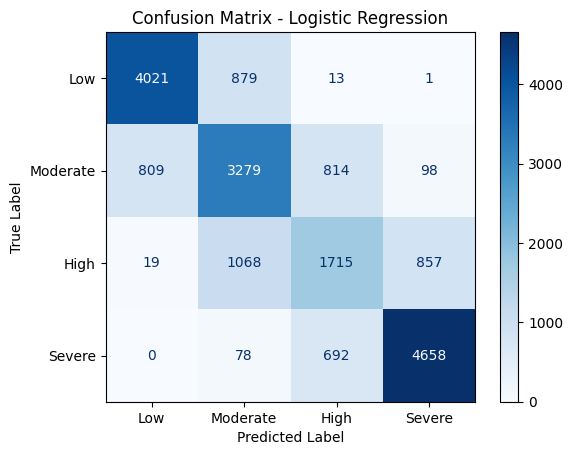

In [39]:
labels = ["Low", "Moderate", "High", "Severe"]

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

3.2. ROC-AUC

In [40]:
# Xác suất dự đoán của từng lớp
y_proba_log = log_model.predict_proba(X_test)

# ROC-AUC cho bài toán đa lớp
roc_auc_log = roc_auc_score(
    y_test,
    y_proba_log,
    multi_class="ovr",
    average="weighted"
)
print("ROC-AUC Logistic Regression:", round(roc_auc_log, 4))
precision_log = precision_score(
    y_test, y_pred_log, average="weighted"
)
recall_log = recall_score(
    y_test, y_pred_log, average="weighted"
)
f1_log = f1_score(
    y_test, y_pred_log, average="weighted"
)
results = pd.DataFrame({
    "Chỉ số": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Giá trị": [
        accuracy_log,
        precision_log,
        recall_log,
        f1_log,
        roc_auc_log
    ]
})
results["Giá trị"] = results["Giá trị"].round(4)
display(results)

ROC-AUC Logistic Regression: 0.9197


,Chỉ số,Giá trị
0,Accuracy,0.7196
1,Precision,0.7163
2,Recall,0.7196
3,F1-Score,0.7173
4,ROC-AUC,0.9197


3.3. kiểm tra overfitting

In [41]:
# Accuracy trên tập Train
train_accuracy = log_model.score(X_train, y_train)

# Accuracy trên tập Test
test_accuracy = log_model.score(X_test, y_test)

print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy :", round(test_accuracy, 4))
print("Chênh lệch    :", round(train_accuracy - test_accuracy, 4))

Train Accuracy: 0.7178
Test Accuracy : 0.7196
Chênh lệch    : -0.0018


4. Dự đoán mức độ Burnout

In [47]:
preprocessor = joblib.load("burnout_preprocessor.joblib")

Các thông tin cần nhập:
['age', 'gender', 'job_role', 'seniority_level', 'years_experience', 'work_mode', 'salary_usd', 'work_hours_per_week', 'sleep_hours_per_night', 'uses_therapy', 'ai_tools_daily', 'deadline_pressure_score', 'stress_score', 'phq9_score', 'gad7_score', 'seeks_mental_health_support', 'job_change_intention']
{'encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False)}


In [53]:
new_person = pd.DataFrame([{
    "age": 25,
    "gender": "Female",
    "job_role": "Data Analyst",
    "seniority_level": "Junior",
    "years_experience": 2,
    "work_mode": "Hybrid",
    "salary_usd": 30000,
    "work_hours_per_week": 45,
    "sleep_hours_per_night": 6.5,
    "uses_therapy": 0,
    "ai_tools_daily": 1,
    "deadline_pressure_score": 7,
    "stress_score": 7,
    "phq9_score": 10,
    "gad7_score": 9,
    "seeks_mental_health_support": 0,
    "job_change_intention": 1
}])
display(new_person)


,age,gender,job_role,seniority_level,years_experience,work_mode,salary_usd,work_hours_per_week,sleep_hours_per_night,uses_therapy,ai_tools_daily,deadline_pressure_score,stress_score,phq9_score,gad7_score,seeks_mental_health_support,job_change_intention
0,25,Female,Data Analyst,Junior,2,Hybrid,30000,45,6.5,0,1,7,7,10,9,0,1


In [55]:
# Tiền xử lý thông tin người mới
new_person_processed = pd.DataFrame(
    preprocessor.transform(new_person),
    columns=preprocessor.get_feature_names_out()
)
prediction = log_model.predict(new_person_processed)
# Chuyển kết quả số thành tên mức độ Burnout
burnout_labels = {
    0: "Low",
    1: "Moderate",
    2: "High",
    3: "Severe"
}
predicted_level = burnout_labels[prediction[0]]

print("Mức độ Burnout dự đoán:", predicted_level)

Mức độ Burnout dự đoán: High
